# WearPath — Sensor Analysis Notebook

Industrial sensor analysis for **predictive maintenance** using the NASA C-MAPSS
turbofan engine degradation dataset (FD001 training split).

This notebook assumes the batch pipeline has already produced:
`data/processed/sensor_features.parquet`.

Run first:
```bash
python scripts/download_cmapss.py
python scripts/run_pipeline.py
```

## 1. Problem Definition

Turbofan engines generate multivariate sensor readings over operating cycles.
As components degrade, sensor trajectories drift until the unit reaches
end-of-life. A data engineering workflow that cleans, validates, and features
these sequences enables remaining useful life (RUL) analytics and maintenance planning.

This notebook explores the FD001 run-to-failure training trajectories to:
- quantify data quality,
- characterize sensor behavior over cycles,
- inspect engineered rolling/delta features,
- relate selected signals to derived RUL.

## 2. Dataset Overview

| Concept | Meaning in C-MAPSS |
|---|---|
| Engine | One simulated turbofan unit (`engine_id`) with its own degradation trajectory |
| Cycle | One operational time step for that engine |
| Operating settings | Three controllable/condition inputs (`op_setting_1..3`) |
| Sensors | 21 anonymized measurement channels (`sensor_01..sensor_21`) |

Individual sensors are **not** given semantic physical names in the public release,
so this analysis keeps generic sensor labels.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from wear_path.config import FEATURES_PARQUET, FEATURE_SENSOR_COLS
from wear_path.ingestion import load_raw_data
from wear_path.validation import build_quality_report

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 40)

print("Project root:", ROOT)
print("Features parquet:", FEATURES_PARQUET)

Project root: C:\Users\kajal\OneDrive\Desktop\MachinaPulse
Features parquet: C:\Users\kajal\OneDrive\Desktop\MachinaPulse\data\processed\sensor_features.parquet


## 3. Data Loading

In [2]:
raw = load_raw_data(variant="FD001", split="train")
features = pd.read_parquet(FEATURES_PARQUET)

print("Raw shape:", raw.shape)
print("Features shape:", features.shape)
display(raw.head())
print("\nRaw dtypes:")
print(raw.dtypes)
display(raw.describe().T.head(12))

Raw shape: (20631, 26)
Features shape: (20631, 42)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044



Raw dtypes:
engine_id         int64
cycle             int64
op_setting_1    float64
op_setting_2    float64
op_setting_3    float64
sensor_01       float64
sensor_02       float64
sensor_03       float64
sensor_04       float64
sensor_05       float64
sensor_06       float64
sensor_07       float64
sensor_08       float64
sensor_09       float64
sensor_10       float64
sensor_11       float64
sensor_12       float64
sensor_13       float64
sensor_14       float64
sensor_15       float64
sensor_16       float64
sensor_17         int64
sensor_18         int64
sensor_19       float64
sensor_20       float64
sensor_21       float64
dtype: object


,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.00,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.00,156.0000,362.0000
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.00,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.00,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.00,100.0000,100.0000
sensor_01,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.67,518.6700,518.6700
sensor_02,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.64,643.0000,644.5300
sensor_03,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.10,1594.3800,1616.9100
sensor_04,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.04,1414.5550,1441.4900
sensor_05,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.62,14.6200,14.6200


## 4. Data Quality

In [3]:
report = build_quality_report(raw, stage="notebook_raw")
print("Rows:", report.row_count)
print("Columns:", report.column_count)
print("Engines:", report.n_engines)
print("Cycle range:", report.cycle_min, "→", report.cycle_max)
print("Duplicates:", report.duplicate_count)
print("Missing value columns:", report.missing_value_counts or "none")
print("Invalid values:", report.invalid_value_counts or "none")
print("Checks:")
for k, v in report.checks.items():
    print(f"  {k}: {v}")

missing = raw.isna().sum()
display(missing[missing > 0] if missing.any() else pd.Series({"all_columns": 0}, name="missing_count"))

Rows: 20631
Columns: 26
Engines: 100
Cycle range: 1 → 362
Duplicates: 0
Missing value columns: none
Invalid values: none
Checks:
  required_columns_present: True
  numeric_types_valid: True
  engine_id_valid: True
  cycle_positive: True
  no_infinite_values: True
  no_exact_duplicates: True
  engine_cycle_ordering_valid: True
  has_rows: True


all_columns    0
Name: missing_count, dtype: int64

## 5. Sensor Analysis

In [4]:
sensor_cols = [c for c in FEATURE_SENSOR_COLS if c in features.columns]
engine_life = (
    features.groupby("engine_id")["cycle"]
    .max()
    .rename("max_cycle")
    .reset_index()
)
display(engine_life.describe())

sensor_summary = features[sensor_cols].agg(["mean", "std", "min", "max"]).T
display(sensor_summary)

,engine_id,max_cycle
count,100.000000,100.000000
mean,50.500000,206.310000
std,29.011492,46.342749
min,1.000000,128.000000
25%,25.750000,177.000000
50%,50.500000,199.000000
75%,75.250000,229.250000
max,100.000000,362.000000


,mean,std,min,max
sensor_02,642.680934,0.500053,641.2100,644.5300
sensor_03,1590.523119,6.131150,1571.0400,1616.9100
sensor_04,1408.933782,9.000605,1382.2500,1441.4900
sensor_07,553.367711,0.885092,549.8500,556.0600
sensor_11,47.541168,0.267087,46.8500,48.5300
sensor_12,521.413470,0.737553,518.6900,523.3800
sensor_15,8.442146,0.037505,8.3249,8.5848


## 6. Time-Series Trends

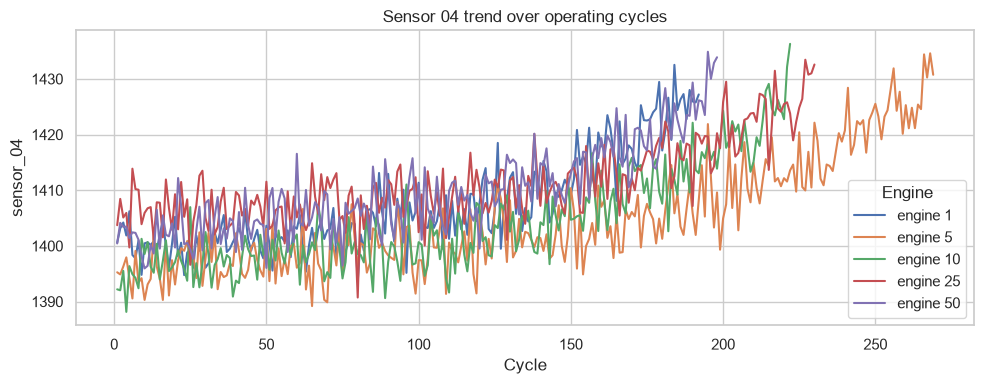

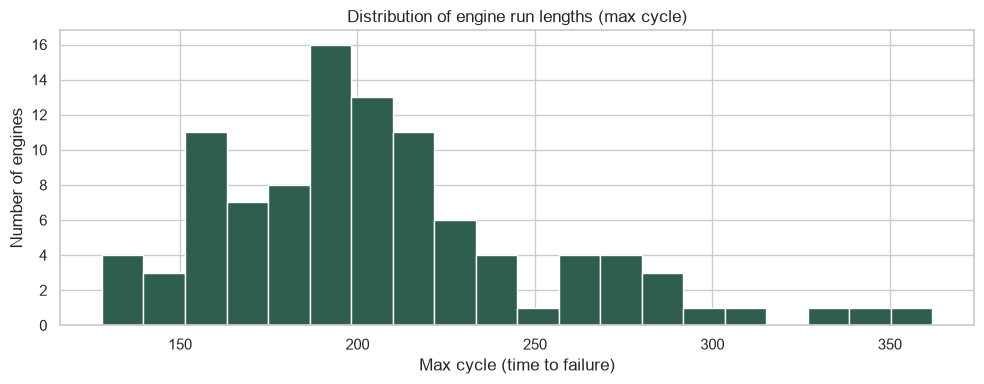

In [5]:
# Plot 1: sensor_04 over cycles for selected engines
sample_engines = [1, 5, 10, 25, 50]
sample = features[features["engine_id"].isin(sample_engines)]

fig, ax = plt.subplots()
for eng, grp in sample.groupby("engine_id"):
    ax.plot(grp["cycle"], grp["sensor_04"], label=f"engine {eng}")
ax.set_title("Sensor 04 trend over operating cycles")
ax.set_xlabel("Cycle")
ax.set_ylabel("sensor_04")
ax.legend(title="Engine")
plt.tight_layout()
plt.show()

# Plot 2: compare end-of-life lengths
fig, ax = plt.subplots()
ax.hist(engine_life["max_cycle"], bins=20, color="#2f5d50", edgecolor="white")
ax.set_title("Distribution of engine run lengths (max cycle)")
ax.set_xlabel("Max cycle (time to failure)")
ax.set_ylabel("Number of engines")
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

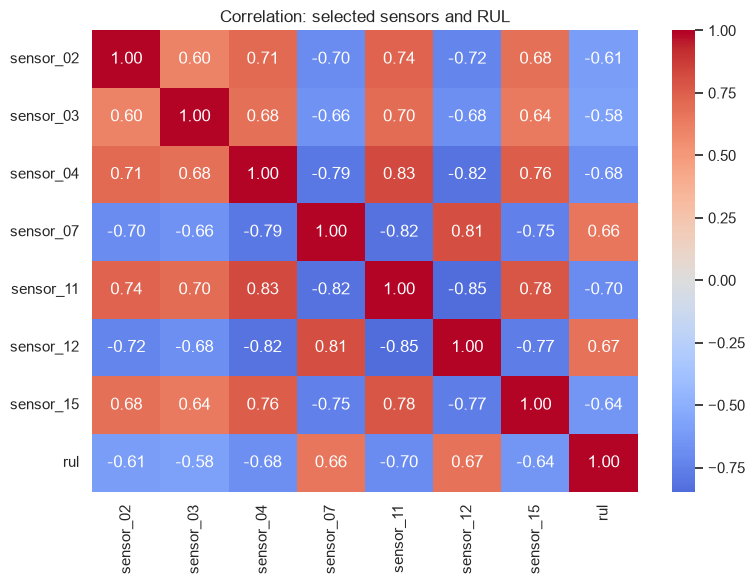

Correlation with RUL (sorted):


,corr_with_rul
sensor_11,-0.696228
sensor_04,-0.678948
sensor_15,-0.642667
sensor_02,-0.606484
sensor_03,-0.584520
sensor_07,0.657223
sensor_12,0.671983


In [6]:
corr_cols = sensor_cols + (["rul"] if "rul" in features.columns else [])
corr = features[corr_cols].corr()

# Plot 3: correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation: selected sensors and RUL")
plt.tight_layout()
plt.show()

if "rul" in corr.columns:
    rul_corr = corr["rul"].drop(labels=["rul"]).sort_values()
    print("Correlation with RUL (sorted):")
    display(rul_corr.to_frame("corr_with_rul"))

## 8. Feature Analysis

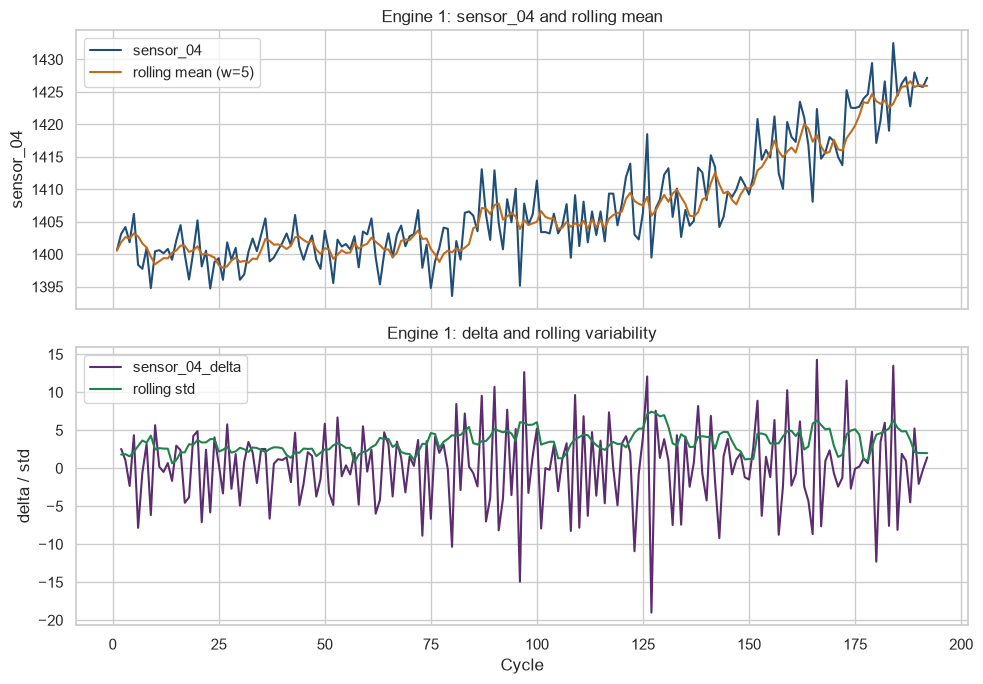

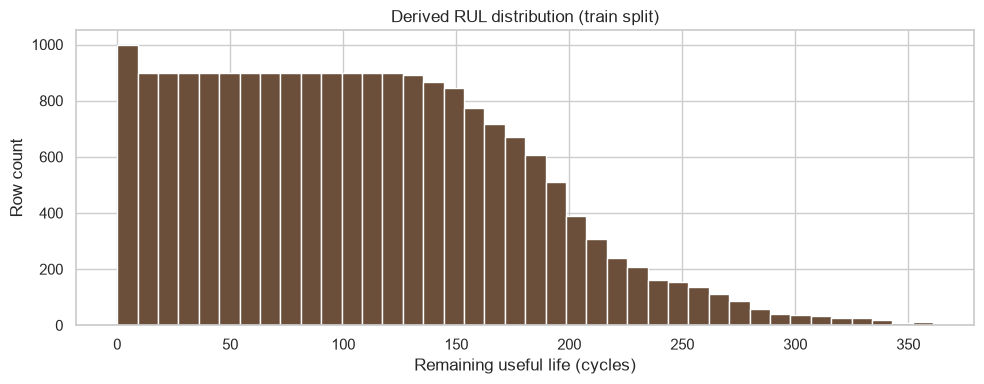

In [7]:
engine_id = 1
one = features[features["engine_id"] == engine_id].sort_values("cycle")

# Plot 4: raw vs rolling mean / delta for sensor_04
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(one["cycle"], one["sensor_04"], label="sensor_04", color="#1f4e79")
axes[0].plot(one["cycle"], one["sensor_04_rolling_mean"], label="rolling mean (w=5)", color="#c46b1a")
axes[0].set_ylabel("sensor_04")
axes[0].set_title(f"Engine {engine_id}: sensor_04 and rolling mean")
axes[0].legend()

axes[1].plot(one["cycle"], one["sensor_04_delta"], label="sensor_04_delta", color="#5b2c6f")
axes[1].plot(one["cycle"], one["sensor_04_rolling_std"], label="rolling std", color="#1e8449")
axes[1].set_xlabel("Cycle")
axes[1].set_ylabel("delta / std")
axes[1].set_title(f"Engine {engine_id}: delta and rolling variability")
axes[1].legend()
plt.tight_layout()
plt.show()

# Plot 5: RUL distribution
if "rul" in features.columns:
    fig, ax = plt.subplots()
    ax.hist(features["rul"], bins=40, color="#6b4f3a", edgecolor="white")
    ax.set_title("Derived RUL distribution (train split)")
    ax.set_xlabel("Remaining useful life (cycles)")
    ax.set_ylabel("Row count")
    plt.tight_layout()
    plt.show()

## 9. Outlier / Anomaly Exploration

We flag statistical outliers with the IQR rule on `sensor_04`.
These are **not** claimed to be equipment failures — they are unusual values
relative to the empirical distribution and may reflect operating variability.

sensor_04 IQR fences: [1384.0675, 1432.8475]
Flagged rows: 120 (0.58%)


C:\Users\kajal\AppData\Local\Temp\ipykernel_6232\2246063402.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s.to_numpy(), vert=True, tick_labels=["sensor_04"])


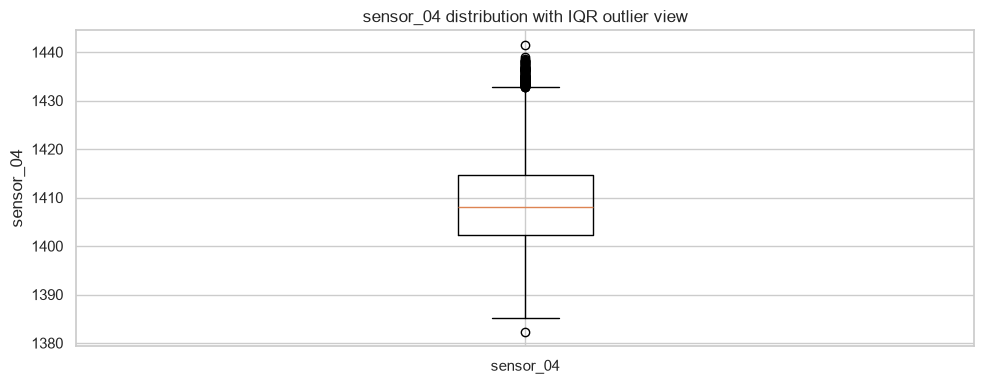

In [8]:
s = features["sensor_04"]
q1, q3 = s.quantile(0.25), s.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_mask = (s < lower) | (s > upper)
n_outliers = int(outlier_mask.sum())
print(f"sensor_04 IQR fences: [{lower:.4f}, {upper:.4f}]")
print(f"Flagged rows: {n_outliers:,} ({100 * n_outliers / len(features):.2f}%)")

fig, ax = plt.subplots()
ax.boxplot(s.to_numpy(), vert=True, tick_labels=["sensor_04"])
ax.set_title("sensor_04 distribution with IQR outlier view")
ax.set_ylabel("sensor_04")
plt.tight_layout()
plt.show()

## 10. Optional ML Baseline (Random Forest RUL)

Secondary to the data engineering focus. Simple holdout by engine to reduce leakage.

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_df = features.dropna().copy()
leakage_cols = {"engine_id", "rul", "cycle", "cycle_norm"}
feature_cols = [
    c for c in model_df.columns
    if c not in leakage_cols and pd.api.types.is_numeric_dtype(model_df[c])
]
print("Using features:", feature_cols)
engines = np.array(sorted(model_df["engine_id"].unique()))
rng = np.random.default_rng(42)
rng.shuffle(engines)
split_at = int(0.8 * len(engines))
train_engines, test_engines = set(engines[:split_at]), set(engines[split_at:])

train = model_df[model_df["engine_id"].isin(train_engines)]
test = model_df[model_df["engine_id"].isin(test_engines)]

X_train, y_train = train[feature_cols], train["rul"]
X_test, y_test = test[feature_cols], test["rul"]

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)
print(f"Test engines: {len(test_engines)}")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

Using features: ['sensor_02', 'sensor_03', 'sensor_04', 'sensor_07', 'sensor_11', 'sensor_12', 'sensor_15', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_02_norm', 'sensor_02_delta', 'sensor_02_rolling_mean', 'sensor_02_rolling_std', 'sensor_03_norm', 'sensor_03_delta', 'sensor_03_rolling_mean', 'sensor_03_rolling_std', 'sensor_04_norm', 'sensor_04_delta', 'sensor_04_rolling_mean', 'sensor_04_rolling_std', 'sensor_07_norm', 'sensor_07_delta', 'sensor_07_rolling_mean', 'sensor_07_rolling_std', 'sensor_11_norm', 'sensor_11_delta', 'sensor_11_rolling_mean', 'sensor_11_rolling_std', 'sensor_12_norm', 'sensor_12_delta', 'sensor_12_rolling_mean', 'sensor_12_rolling_std', 'sensor_15_norm', 'sensor_15_delta', 'sensor_15_rolling_mean', 'sensor_15_rolling_std']


Test engines: 20
MAE:  31.338
RMSE: 43.183
R²:   0.592


## 11. Key Findings

Findings below are computed from the loaded dataset (not pre-written claims).

In [10]:
findings = {
    "n_rows_raw": int(len(raw)),
    "n_engines": int(raw["engine_id"].nunique()),
    "cycle_min": int(raw["cycle"].min()),
    "cycle_max": int(raw["cycle"].max()),
    "mean_engine_life": float(engine_life["max_cycle"].mean()),
    "median_engine_life": float(engine_life["max_cycle"].median()),
    "duplicate_rows_raw": int(report.duplicate_count),
    "missing_cells_raw": int(raw.isna().sum().sum()),
    "sensor_04_outlier_pct": float(100 * n_outliers / len(features)),
}
if "rul" in corr.columns:
    findings["strongest_negative_corr_with_rul"] = rul_corr.idxmin()
    findings["strongest_negative_corr_value"] = float(rul_corr.min())
    findings["strongest_positive_corr_with_rul"] = rul_corr.idxmax()
    findings["strongest_positive_corr_value"] = float(rul_corr.max())

print("Key findings from this run:")
for k, v in findings.items():
    print(f"- {k}: {v}")

print("\nNarrative summary:")
print(
    f"FD001 train contains {findings['n_engines']} engines and {findings['n_rows_raw']:,} cycle observations. "
    f"Engine lifetimes average {findings['mean_engine_life']:.1f} cycles "
    f"(median {findings['median_engine_life']:.1f}). "
    f"Raw missing cells={findings['missing_cells_raw']}, duplicates={findings['duplicate_rows_raw']}. "
    f"IQR outliers on sensor_04 cover {findings['sensor_04_outlier_pct']:.2f}% of feature rows."
)
if "strongest_negative_corr_with_rul" in findings:
    print(
        f"Among selected sensors, {findings['strongest_negative_corr_with_rul']} has the strongest "
        f"negative correlation with RUL ({findings['strongest_negative_corr_value']:.3f}), "
        f"while {findings['strongest_positive_corr_with_rul']} has the strongest positive "
        f"correlation ({findings['strongest_positive_corr_value']:.3f})."
    )

Key findings from this run:
- n_rows_raw: 20631
- n_engines: 100
- cycle_min: 1
- cycle_max: 362
- mean_engine_life: 206.31
- median_engine_life: 199.0
- duplicate_rows_raw: 0
- missing_cells_raw: 0
- sensor_04_outlier_pct: 0.5816489748436818
- strongest_negative_corr_with_rul: sensor_11
- strongest_negative_corr_value: -0.6962281014553727
- strongest_positive_corr_with_rul: sensor_12
- strongest_positive_corr_value: 0.6719831036133275

Narrative summary:
FD001 train contains 100 engines and 20,631 cycle observations. Engine lifetimes average 206.3 cycles (median 199.0). Raw missing cells=0, duplicates=0. IQR outliers on sensor_04 cover 0.58% of feature rows.
Among selected sensors, sensor_11 has the strongest negative correlation with RUL (-0.696), while sensor_12 has the strongest positive correlation (0.672).
